# Numerical Derivatives: Finite Differences

**This notebook is self-contained; it recaps the difference quotient before building on it.**

The rules from §3.3 need a **formula** to differentiate. Real data doesn't come with one — a sensor
gives you a column of numbers, not an equation. So we go back to the definition, stop taking the
limit, and just use a small $h$. That is a **finite difference**, and it is how derivatives are
actually computed in practice.

The catch, and the point of this notebook: the answer is now an approximation, and **how you arrange
the arithmetic changes how good it is**.

## Learning objectives

- Compute **forward**, **backward**, and **central** difference approximations to $f'$.
- Compare their accuracy against a known true derivative.
- Discover, by measurement, that the error shrinks at different **rates** — and that shrinking $h$
  too far makes things *worse*.

## Background

The derivative is $f'(x) = \lim_{h\to 0}\frac{f(x+h)-f(x)}{h}$. Stop before the limit and there are
three natural ways to arrange it:

$$\text{forward: } \frac{f(x+h) - f(x)}{h}, \qquad
  \text{backward: } \frac{f(x) - f(x-h)}{h}, \qquad
  \text{central: } \frac{f(x+h) - f(x-h)}{2h}$$

Forward looks ahead, backward looks behind, and central straddles the point — using a symmetric pair
either side. All three approach $f'(x)$ as $h \to 0$, but not at the same speed. We will **measure**
which is better rather than assume it.

There is also a floor. From §3.1, floating-point arithmetic carries about $10^{-16}$ of relative
error. Dividing two nearly-equal numbers by a tiny $h$ amplifies that error, so past a certain point
shrinking $h$ makes the answer *worse*, not better.

## This notebook covers

1. The three stencils on a known function.
2. Error versus step size, measured.
3. The accuracy floor: when smaller $h$ stops helping.
4. Differentiating sampled data with no formula at all.

**Prerequisites:** `U3-3_Derivatives-1_SecantToTangent`, `U3-1_Approximation-1_ModelsAndError`

**Dataset:** none here — a known function, so the true answer is available for comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The three stencils

Use $f(x) = x^3$, whose derivative we know exactly is $f'(x) = 3x^2$ — that known answer is what makes
measuring the error possible. Apply all three formulas with a deliberately large $h = 1$ so the
differences are visible.

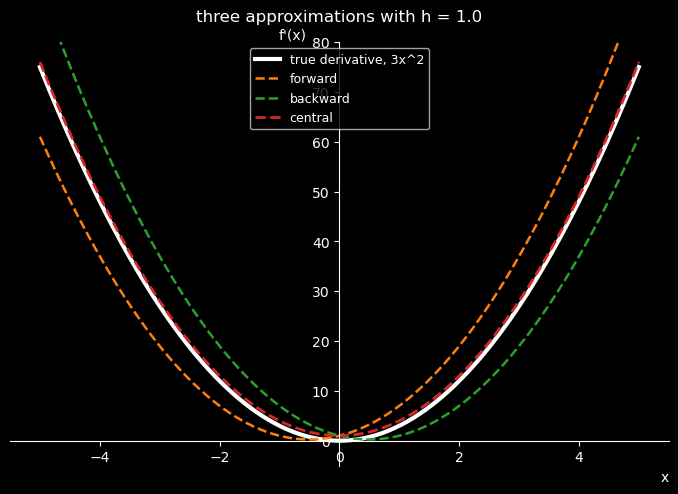

In [2]:
def f(x):
    return x**3

def df_true(x):
    return 3*x**2

xs = np.linspace(-5, 5, 200)
h = 1.0

forward  = (f(xs + h) - f(xs)) / h
backward = (f(xs) - f(xs - h)) / h
central  = (f(xs + h) - f(xs - h)) / (2*h)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(xs, df_true(xs), color="white", lw=3, label="true derivative, 3x^2")
ax.plot(xs, forward, "--", color="tab:orange", lw=1.8, label="forward")
ax.plot(xs, backward, "--", color="tab:green", lw=1.8, label="backward")
ax.plot(xs, central, "--", color="tab:red", lw=2, label="central")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f'(x)", loc="top", rotation=0)
ax.set_ylim(-5, 80)
ax.legend(loc="upper center", fontsize=9)
ax.set_title(f"three approximations with h = {h}", pad=15)
plt.show()

Forward sits above the truth, backward below — each is offset in the direction it looks. **Central
lands almost exactly on it**, because its two one-sided errors point opposite ways and largely cancel.

That is a picture, though, not a measurement. Let us get a number.

## 2. Error versus step size

Fix a point, shrink $h$, and record the error for each method. Plotting on **log-log** axes turns a
power-law relationship into a straight line, and the **slope of that line** tells you how fast the
error shrinks.

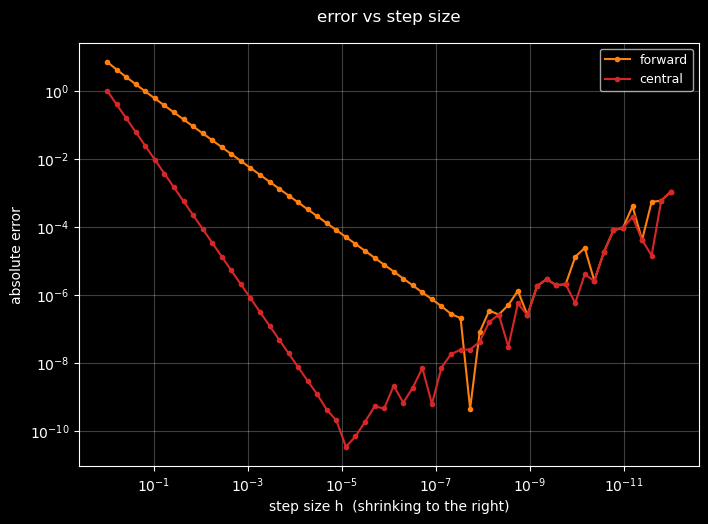

In [3]:
x0 = 2.0
truth = df_true(x0)
hs = np.logspace(0, -12, 60)

err_forward = np.abs((f(x0 + hs) - f(x0)) / hs - truth)
err_central = np.abs((f(x0 + hs) - f(x0 - hs)) / (2*hs) - truth)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(hs, err_forward, "o-", color="tab:orange", markersize=3, label="forward")
ax.loglog(hs, err_central, "o-", color="tab:red", markersize=3, label="central")
ax.invert_xaxis()
ax.set_xlabel("step size h  (shrinking to the right)")
ax.set_ylabel("absolute error")
ax.set_title("error vs step size", pad=15)
ax.legend(fontsize=9)
ax.grid(alpha=0.25, which="both")
plt.show()

In [4]:
# measure the slopes on the clean (left) part of the curve, before round-off takes over
def measured_slope(hs, errs, lo=1e-5, hi=1e-1):
    m = (hs > lo) & (hs < hi) & (errs > 0)
    return np.polyfit(np.log10(hs[m]), np.log10(errs[m]), 1)[0]

print(f"measured log-log slope, forward : {measured_slope(hs, err_forward):.2f}")
print(f"measured log-log slope, central : {measured_slope(hs, err_central):.2f}")

measured log-log slope, forward : 1.00
measured log-log slope, central : 2.00


Read those two slopes as a promise about what shrinking $h$ buys you:

- **slope 1** — halve $h$ and you halve the error.
- **slope 2** — halve $h$ and you *quarter* it. Far better value for the same work.

These are written $O(h)$ and $O(h^2)$. Why those particular powers has a clean explanation, but
it needs Taylor series — `U3-9_Taylor-1_PolynomialApproximation`, at the end of this unit, closes
the loop and derives them.


## 3. The floor: when smaller stops being better

Look again at the log-log plot and follow the curves to the right. They fall, then **turn around and
climb**. Past roughly $h = 10^{-8}$, making the step smaller makes the answer *worse*.

This is the floating-point error from §3.1 asserting itself. $f(x+h)$ and $f(x)$ become nearly
identical numbers; subtracting them cancels almost all the significant digits, and then dividing by a
tiny $h$ blows up whatever rounding noise is left.

**There is a best $h$**, and it is nowhere near zero.

In [5]:
best_f = hs[np.argmin(err_forward)]
best_c = hs[np.argmin(err_central)]
print(f"forward: best h = {best_f:.1e}  giving error {err_forward.min():.2e}")
print(f"central: best h = {best_c:.1e}  giving error {err_central.min():.2e}")
print()
print("at h = 1e-14, the subtraction has lost almost every significant digit:")
tiny = 1e-14
print(f"   f(x0 + h) = {f(x0 + tiny):.17f}")
print(f"   f(x0)     = {f(x0):.17f}")
print(f"   difference= {f(x0 + tiny) - f(x0):.17e}   <- almost pure rounding noise")
print(f"   divided by h -> {(f(x0 + tiny) - f(x0))/tiny:.6f}   (true answer: {truth})")

forward: best h = 1.9e-08  giving error 4.41e-10
central: best h = 8.2e-06  giving error 3.32e-11

at h = 1e-14, the subtraction has lost almost every significant digit:
   f(x0 + h) = 8.00000000000012257
   f(x0)     = 8.00000000000000000
   difference= 1.22568621918617282e-13   <- almost pure rounding noise
   divided by h -> 12.256862   (true answer: 12.0)


So numerical differentiation has a genuine sweet spot: large $h$ suffers from the approximation,
small $h$ suffers from round-off, and the best accuracy sits between them. That trade-off is a
recurring feature of numerical methods, not a quirk of this example.

## 4. When there is no formula

The real motivation. Suppose all you have is a set of sampled points — a sensor log, a patient's vitals
— and no equation. The rules of §3.3 are useless; finite differences are not, because they only need
values.

With $n$ data points you get $n-1$ forward differences (each sits *between* two samples) or $n-2$
central differences. Note also that the resolution of your data sets the smallest $h$ available: you
cannot choose $h$ freely, you get whatever the sampling interval gives you.

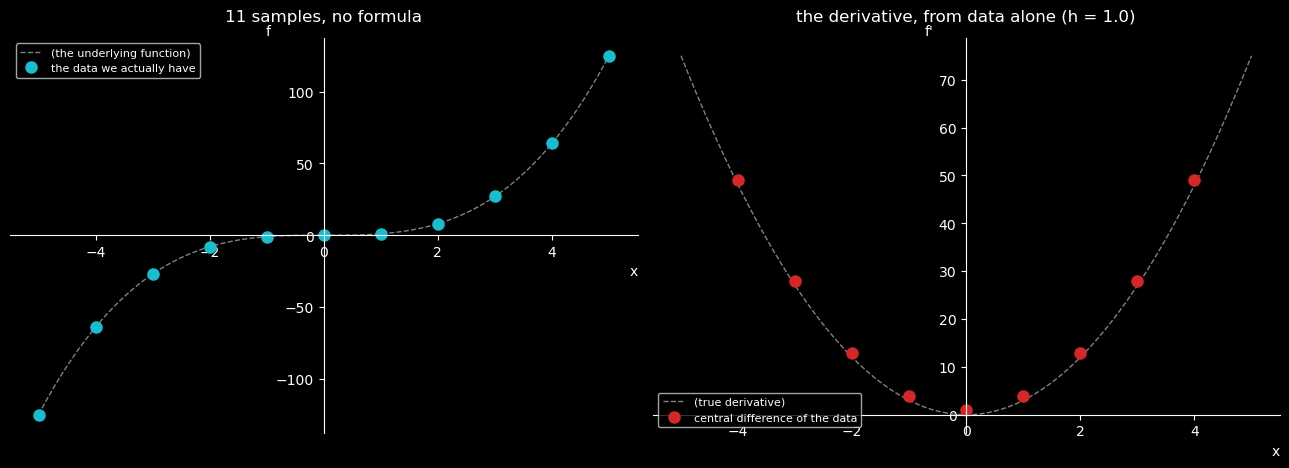

11 data points -> 9 central differences (the two endpoints have no neighbour on one side)


In [6]:
# pretend we only have 11 samples, with no formula behind them
t_data = np.linspace(-5, 5, 11)
y_data = f(t_data)
dt = t_data[1] - t_data[0]

# central differences, valid only at the interior points
d_central = (y_data[2:] - y_data[:-2]) / (2*dt)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(xs, f(xs), "--", color="gray", lw=1, label="(the underlying function)")
axes[0].plot(t_data, y_data, "o", color="tab:cyan", markersize=8, label="the data we actually have")
axes[0].set_title("11 samples, no formula", pad=12)

axes[1].plot(xs, df_true(xs), "--", color="gray", lw=1, label="(true derivative)")
axes[1].plot(t_data[1:-1], d_central, "o", color="tab:red", markersize=8,
             label="central difference of the data")
axes[1].set_title(f"the derivative, from data alone (h = {dt:.1f})", pad=12)

for ax in axes:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.legend(fontsize=8)
axes[0].set_ylabel("f", loc="top", rotation=0)
axes[1].set_ylabel("f'", loc="top", rotation=0)
plt.tight_layout()
plt.show()

print(f"{len(y_data)} data points -> {len(d_central)} central differences "
      f"(the two endpoints have no neighbour on one side)")

## 5. Summary

- **Finite differences** approximate $f'$ from values alone — no formula needed. Forward, backward,
  and central are the three arrangements.
- **Central is markedly more accurate** for the same $h$, because its one-sided errors cancel.
- Measured on log-log axes, forward's error falls with slope $\approx 1$ and central's with slope
  $\approx 2$ — written $O(h)$ and $O(h^2)$. §3.9 explains where those powers come from.
- **Smaller $h$ is not always better.** Past the sweet spot — around $10^{-8}$ for forward and
  $10^{-5}$ for central — floating-point cancellation dominates and accuracy degrades. There is a best
  step size, and it is different for each method.
- With sampled data you don't get to choose $h$ — the sampling interval chooses it for you.

Next: what happens when the data is **noisy**, which is the usual case, and how to cope
(`U3-4_NumericalDerivatives-2_Noise`).